# Titanic EDA and Visualization Practice

**Author:** Girivikas P  
**Dataset:** Titanic passenger data  
**Objective:** Exploratory data analysis and visualization to understand survival patterns

### Sections
1. Libraries
2. Data Import
3. EDA
   - 3.1 Survival Rate
   - 3.2 Age Analysis by Survival
   - 3.3 Survival by Passenger Class
   - 3.4 Missing Value Analysis
4. Data Cleaning
5. Visualization

## 1. Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 2. Data Import

Loading the Titanic dataset from a public GitHub repository.

In [2]:
DATA_URL = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

df = pd.read_csv(DATA_URL)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
# Dataset shape and column types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [4]:
# Summary statistics
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## 3. EDA

### 3.1 Survival Rate

Overall survival rate across all 891 passengers.

In [5]:
survival_rate = df['Survived'].mean()
print(f"Overall survival rate: {survival_rate:.2%}")
print(f"Total survivors: {df['Survived'].sum()} out of {len(df)} passengers")

Overall survival rate: 38.38%
Total survivors: 342 out of 891 passengers


### 3.2 Age Analysis by Survival

Comparing average age between survivors and non-survivors.

In [6]:
age_by_survival = df.groupby('Survived')['Age'].mean()
print("Average age by survival status:")
print(f"  Did not survive: {age_by_survival[0]:.2f} years")
print(f"  Survived:        {age_by_survival[1]:.2f} years")

Average age by survival status:
  Did not survive: 30.63 years
  Survived:        28.34 years


### 3.3 Survival by Passenger Class

Survival counts and rates broken down by Pclass (1 = First, 2 = Second, 3 = Third).

In [7]:
survival_by_class = df.groupby('Pclass')['Survived'].agg(['sum', 'count', 'mean'])
survival_by_class.columns = ['Survivors', 'Total', 'Survival Rate']
survival_by_class['Survival Rate'] = survival_by_class['Survival Rate'].map('{:.1%}'.format)
print(survival_by_class)

        Survivors  Total Survival Rate
Pclass                                
1             136    216         63.0%
2              87    184         47.3%
3             119    491         24.2%


### 3.4 Missing Value Analysis

Identifying columns with missing data before cleaning.

In [8]:
missing_counts = df.isnull().sum()
missing_counts = missing_counts[missing_counts > 0]
print("Missing values per column:")
print(missing_counts)

Missing values per column:
Age         177
Cabin       687
Embarked      2
dtype: int64


## 4. Data Cleaning

Filling missing Age values with the median age to preserve the distribution.

In [9]:
age_median = df['Age'].median()
df['Age'] = df['Age'].fillna(age_median)

print(f"Age median used for imputation: {age_median}")
print(f"Remaining missing Age values: {df['Age'].isnull().sum()}")

Age median used for imputation: 28.0
Remaining missing Age values: 0


## 5. Visualization

Three charts to visualise survival patterns in the Titanic dataset.

All plots use Matplotlib OOP style (`fig, ax = plt.subplots()`).

### 5.1 Survival Count Bar Chart

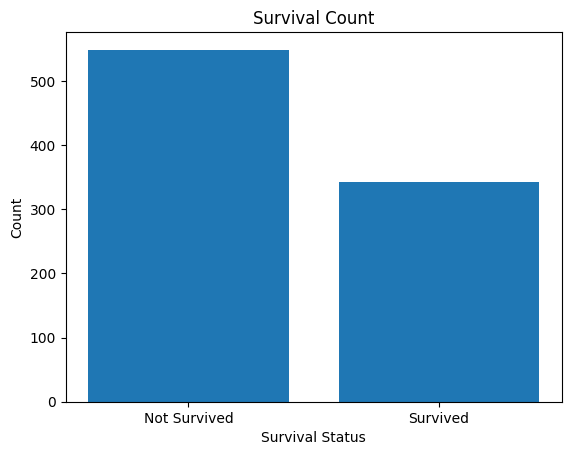

In [10]:
survival_counts = df['Survived'].value_counts().sort_index()

fig, ax = plt.subplots()
ax.bar(['Not Survived', 'Survived'], survival_counts.values)
ax.set_title('Survival Count')
ax.set_xlabel('Survival Status')
ax.set_ylabel('Count')
plt.show()

### 5.2 Age Distribution by Survival Status

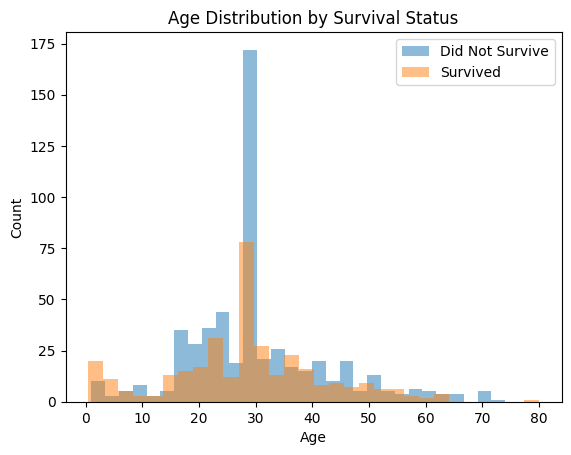

In [11]:
fig, ax = plt.subplots()
ax.hist(df[df['Survived'] == 0]['Age'], alpha=0.5, bins=30, label='Did Not Survive')
ax.hist(df[df['Survived'] == 1]['Age'], alpha=0.5, bins=30, label='Survived')
ax.set_title('Age Distribution by Survival Status')
ax.set_xlabel('Age')
ax.set_ylabel('Count')
ax.legend()
plt.show()

### 5.3 Survival Rate by Passenger Class

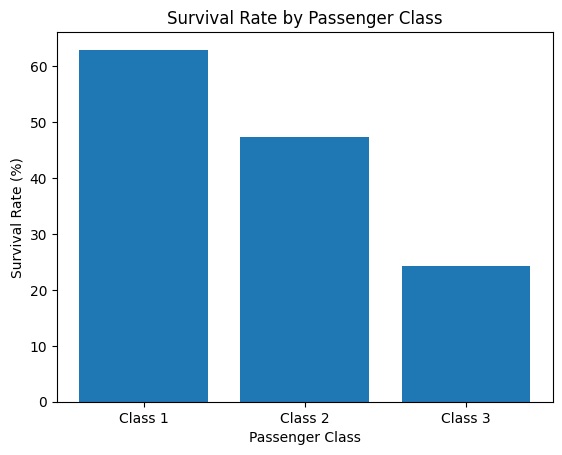

In [12]:
survival_rate_by_class = df.groupby('Pclass')['Survived'].mean() * 100

fig, ax = plt.subplots()
ax.bar(['Class 1', 'Class 2', 'Class 3'], survival_rate_by_class.values)
ax.set_title('Survival Rate by Passenger Class')
ax.set_xlabel('Passenger Class')
ax.set_ylabel('Survival Rate (%)')
plt.show()